
Training with Learning Rate: 0.01
Final Mean Squared Error: 0.24996

XOR Gate Results:
Input: [0 0] Predicted Output: [0.5]
Input: [0 1] Predicted Output: [0.5]
Input: [1 0] Predicted Output: [0.5]
Input: [1 1] Predicted Output: [0.5]

Training with Learning Rate: 0.1
Final Mean Squared Error: 0.13349

XOR Gate Results:
Input: [0 0] Predicted Output: [0.5]
Input: [0 1] Predicted Output: [0.48]
Input: [1 0] Predicted Output: [0.92]
Input: [1 1] Predicted Output: [0.1]

Training with Learning Rate: 0.5
Stopped early at epoch 1008 with error: 0.00998
Final Mean Squared Error: 0.00998

XOR Gate Results:
Input: [0 0] Predicted Output: [0.1]
Input: [0 1] Predicted Output: [0.9]
Input: [1 0] Predicted Output: [0.9]
Input: [1 1] Predicted Output: [0.11]


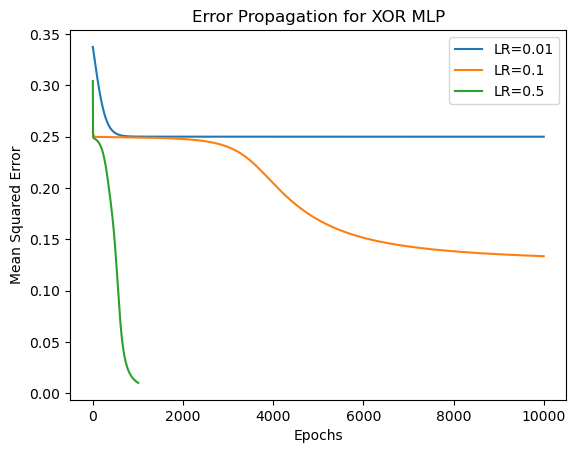

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

inputs = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

outputs = np.array([
    [0],
    [1],
    [1],
    [0]
])

epochs = 10000
learning_rates = [0.01, 0.1, 0.5]
np.random.seed(0)

for lr in learning_rates:
    print(f"\nTraining with Learning Rate: {lr}")
    hidden_weights = np.random.uniform(-1, 1, (2, 2))
    hidden_bias = np.random.uniform(-1, 1, (1, 2))
    output_weights = np.random.uniform(-1, 1, (2, 1))
    output_bias = np.random.uniform(-1, 1, (1, 1))
    errors = []

    for epoch in range(epochs):
        hidden_layer_input = np.dot(inputs, hidden_weights) + hidden_bias
        hidden_layer_output = sigmoid(hidden_layer_input)
        output_layer_input = np.dot(hidden_layer_output, output_weights) + output_bias
        predicted_output = sigmoid(output_layer_input)
        error = predicted_output - outputs
        mean_squared_error = np.mean(np.square(error))
        errors.append(mean_squared_error)
        d_predicted_output = error * sigmoid_derivative(predicted_output)
        d_hidden_layer = np.dot(d_predicted_output, output_weights.T) * sigmoid_derivative(hidden_layer_output)
        output_weights -= np.dot(hidden_layer_output.T, d_predicted_output) * lr
        output_bias -= np.sum(d_predicted_output, axis=0, keepdims=True) * lr
        hidden_weights -= np.dot(inputs.T, d_hidden_layer) * lr
        hidden_bias -= np.sum(d_hidden_layer, axis=0, keepdims=True) * lr
        if mean_squared_error < 0.01:
            print(f"Stopped early at epoch {epoch + 1} with error: {mean_squared_error:.5f}")
            break

    print(f"Final Mean Squared Error: {mean_squared_error:.5f}")
    print("\nXOR Gate Results:")
    for i in range(len(inputs)):
        hidden_layer_input = np.dot(inputs[i], hidden_weights) + hidden_bias
        hidden_layer_output = sigmoid(hidden_layer_input)
        output_layer_input = np.dot(hidden_layer_output, output_weights) + output_bias
        predicted_output = sigmoid(output_layer_input)
        print(f"Input: {inputs[i]} Predicted Output: {np.round(predicted_output[0], 2)}")

    plt.plot(errors, label=f"LR={lr}")

plt.title("Error Propagation for XOR MLP")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()